In [3]:
#1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#2. Load the Datasets
apps_df = pd.read_csv(r"C:\Users\Admin\Downloads\OBSIP\Triveni_Task8\Datasets\apps.csv")
reviews_df = pd.read_csv(r"C:\Users\Admin\Downloads\OBSIP\Triveni_Task8\Datasets\user_reviews.csv")

print(apps_df.head())
print(reviews_df.head())

   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644  25.0  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967   2.8     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  Art & Design;Pretend Play  J

In [5]:
#3. Understand the Dataset
print(apps_df.columns)

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')


In [6]:
#4. Data Cleaning
apps_df = apps_df.drop_duplicates()
reviews_df = reviews_df.drop_duplicates()

print(apps_df.shape)
print(reviews_df.shape)

(9659, 14)
(30679, 5)


In [7]:
#Handle Missing Values
import pandas as pd
import numpy as np

# Remove missing ratings
apps_df = apps_df.dropna(subset=['Rating'])

# -----------------------------
# Convert Reviews Column
# -----------------------------
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

# -----------------------------
# Clean Installs Column
# -----------------------------
apps_df['Installs'] = apps_df['Installs'].astype(str)

apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False)
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '', regex=False)

apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

# -----------------------------
# Clean Price Column
# -----------------------------
apps_df['Price'] = apps_df['Price'].astype(str)

apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False)

apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# -----------------------------
# Clean Size Column
# -----------------------------
apps_df['Size'] = apps_df['Size'].astype(str)

# Replace special text
apps_df['Size'] = apps_df['Size'].replace('Varies with device', np.nan)

# Convert KB to MB
apps_df['Size'] = apps_df['Size'].str.replace('M', '', regex=False)

apps_df['Size'] = apps_df['Size'].str.replace('k', '', regex=False)

# Convert to numeric
apps_df['Size'] = pd.to_numeric(apps_df['Size'], errors='coerce')

# Display cleaned data
print(apps_df.head())

# Check datatypes
print(apps_df.dtypes)

   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size  Installs  Type  Price  \
0  ART_AND_DESIGN     4.1      159  19.0     10000  Free    0.0   
1  ART_AND_DESIGN     3.9      967  14.0    500000  Free    0.0   
2  ART_AND_DESIGN     4.7    87510   8.7   5000000  Free    0.0   
3  ART_AND_DESIGN     4.5   215644  25.0  50000000  Free    0.0   
4  ART_AND_DESIGN     4.3      967   2.8    100000  Free    0.0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  Art & Design;Pretend Play  January 15, 2

Category
FAMILY                 1608
GAME                    912
TOOLS                   718
FINANCE                 302
PRODUCTIVITY            301
LIFESTYLE               301
PERSONALIZATION         298
MEDICAL                 290
BUSINESS                263
PHOTOGRAPHY             263
SPORTS                  260
COMMUNICATION           256
HEALTH_AND_FITNESS      244
NEWS_AND_MAGAZINES      204
SOCIAL                  203
TRAVEL_AND_LOCAL        187
SHOPPING                180
BOOKS_AND_REFERENCE     169
VIDEO_PLAYERS           148
DATING                  134
MAPS_AND_NAVIGATION     118
EDUCATION               118
ENTERTAINMENT           102
FOOD_AND_DRINK           94
AUTO_AND_VEHICLES        73
WEATHER                  72
LIBRARIES_AND_DEMO       64
HOUSE_AND_HOME           62
ART_AND_DESIGN           61
COMICS                   54
PARENTING                50
EVENTS                   45
BEAUTY                   42
Name: count, dtype: int64


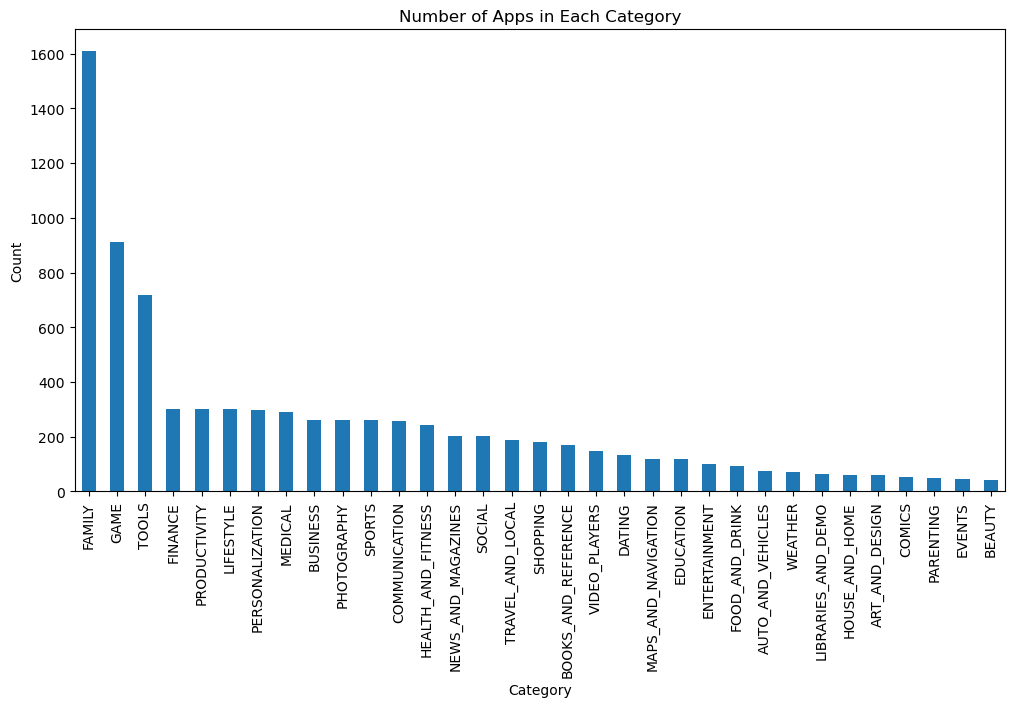

In [8]:
#Exploratory Data Analysis (EDA)
category_counts = apps_df['Category'].value_counts()

print(category_counts)
plt.figure(figsize=(12,6))
category_counts.plot(kind='bar')
plt.title('Number of Apps in Each Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

4.173243045387993
                                            App  Rating
4703         Jobs in Canada - Emplois au Canada     5.0
6120                             CD CHOICE TUBE     5.0
6151                                   CE Smart     5.0
6160  TI-84 CE Graphing Calculator Manual TI 84     5.0
8220                                   EG India     5.0
6998                    cx advance call blocker     5.0
6168                                  MCQ CE IT     5.0
6993                                 Oración CX     5.0
8241                       Eh Bee Wallpapers HD     5.0
6195                                    CF Life     5.0


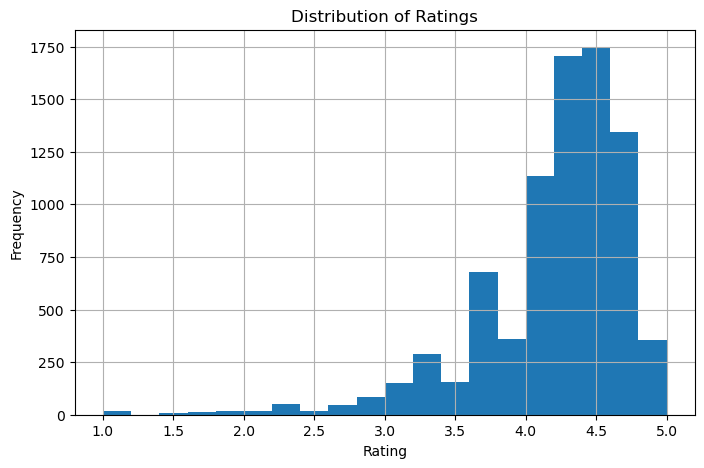

In [9]:
#Rating Analysis
print(apps_df['Rating'].mean())
top_rated = apps_df[['App','Rating']].sort_values(by='Rating', ascending=False)
print(top_rated.head(10))
plt.figure(figsize=(8,5))
apps_df['Rating'].hist(bins=20)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

                                           App    Installs
2977                               Google News  1000000000
2507                                    Google  1000000000
2002                                  Facebook  1000000000
2003                                 Instagram  1000000000
299   Messenger – Text and Video Chat for Free  1000000000
300                         WhatsApp Messenger  1000000000
302               Google Chrome: Fast & Secure  1000000000
304                                      Gmail  1000000000
2012                                   Google+  1000000000
305                                   Hangouts  1000000000


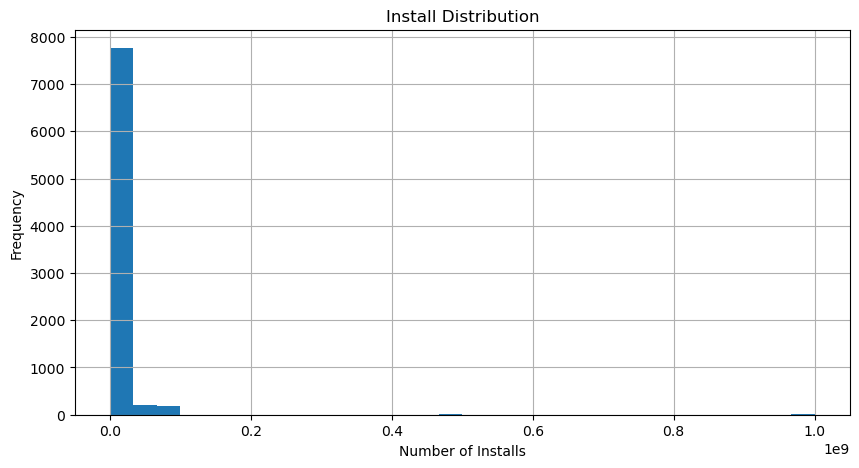

In [10]:
#Install Analysis
top_installs = apps_df[['App','Installs']].sort_values(by='Installs', ascending=False)
print(top_installs.head(10))
plt.figure(figsize=(10,5))
apps_df['Installs'].hist(bins=30)
plt.title('Install Distribution')
plt.xlabel('Number of Installs')
plt.ylabel('Frequency')
plt.show()

Type
Free    7592
Paid     604
Name: count, dtype: int64


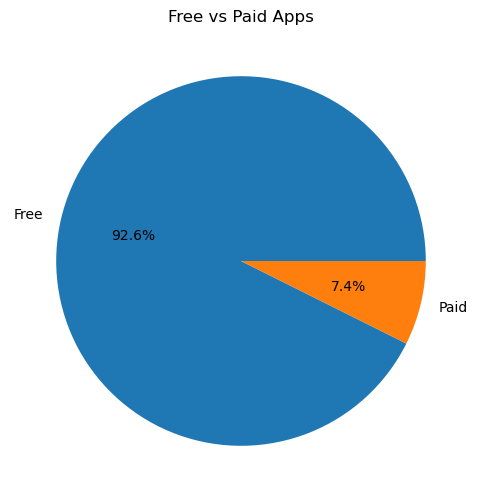

In [11]:
#Paid vs Free Apps
type_count = apps_df['Type'].value_counts()
print(type_count)
plt.figure(figsize=(6,6))
type_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()

                                 App   Price
3469        I'm Rich - Trump Edition  400.00
4406                   I Am Rich Pro  399.99
4398                  I am Rich Plus  399.99
3327          most expensive app (H)  399.99
3465                      💎 I'm rich  399.99
4417              I AM RICH PRO PLUS  399.99
4413                       I am Rich  399.99
4408  I am rich (Most expensive app)  399.99
4403              I am rich(premium)  399.99
4400               I Am Rich Premium  399.99


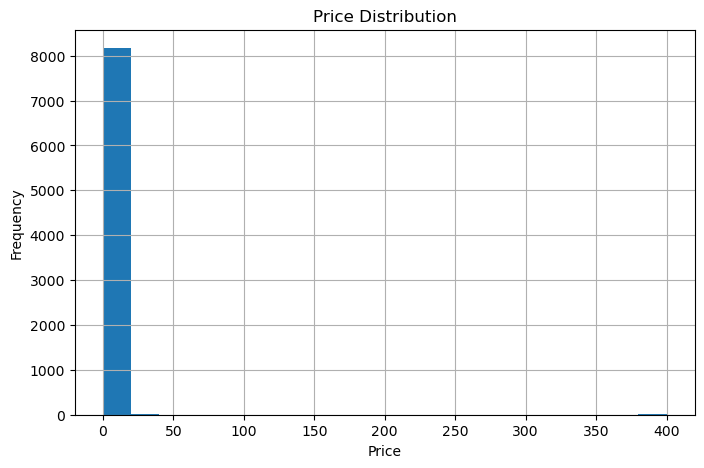

In [12]:
#Price Analysis
expensive_apps = apps_df[['App','Price']].sort_values(by='Price', ascending=False)
print(expensive_apps.head(10))
plt.figure(figsize=(8,5))
apps_df['Price'].hist(bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Sentiment
Positive    19015
Negative     6321
Neutral      4361
Name: count, dtype: int64


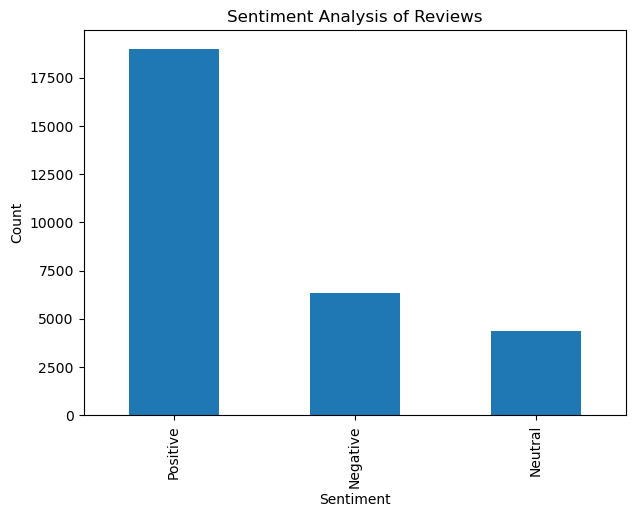

In [13]:
#Sentiment Analysis
sentiment_count = reviews_df['Sentiment'].value_counts()
print(sentiment_count)
plt.figure(figsize=(7,5))
sentiment_count.plot(kind='bar')
plt.title('Sentiment Analysis of Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

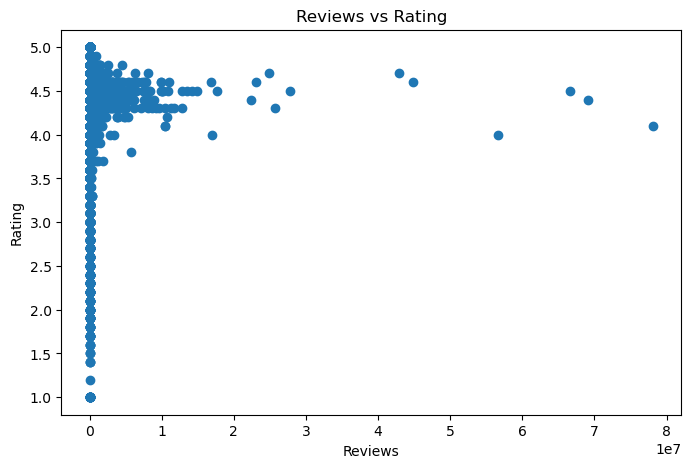

In [14]:
#Correlation Analysis
plt.figure(figsize=(8,5))
plt.scatter(apps_df['Reviews'], apps_df['Rating'])
plt.title('Reviews vs Rating')
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.show()

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247368
SOCIAL                 4.247291
WEATHER                4.243056
Name: Rating, dtype: float64
Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247368
SOCIAL                 4.247291
WEATHER                4.243056
Name: Rating, dtype: float64


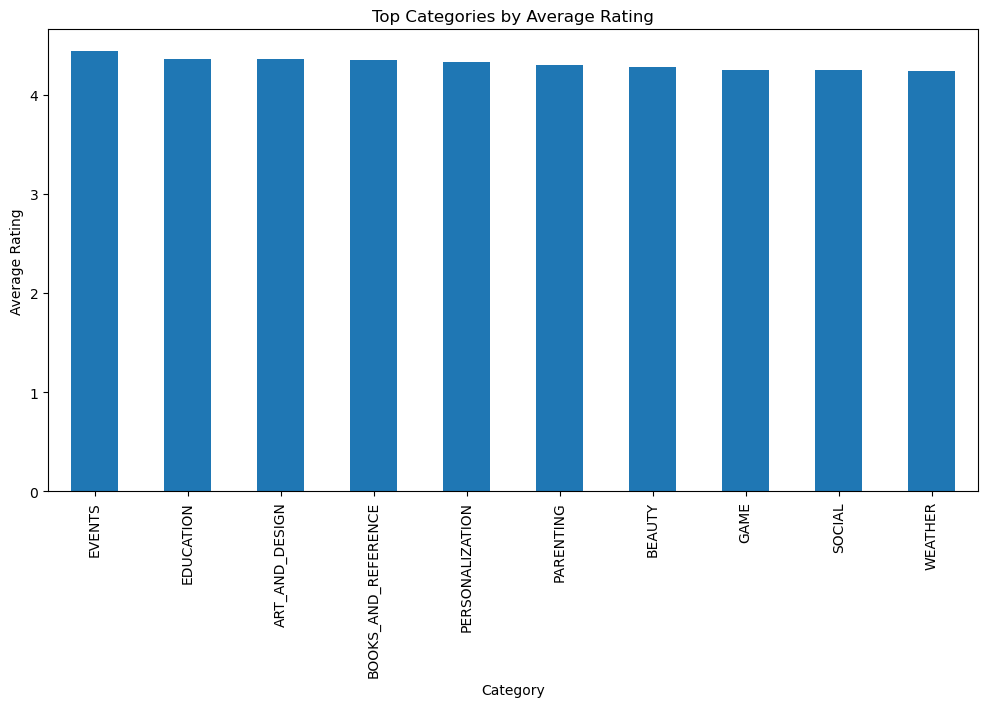

In [15]:
#Top Categories by Average Rating
avg_rating = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)


print(avg_rating.head(10))
print(avg_rating.head(10))
plt.figure(figsize=(12,6))
avg_rating.head(10).plot(kind='bar')
plt.title('Top Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.show()

                                           App    Installs
2977                               Google News  1000000000
2507                                    Google  1000000000
2002                                  Facebook  1000000000
2003                                 Instagram  1000000000
299   Messenger – Text and Video Chat for Free  1000000000
300                         WhatsApp Messenger  1000000000
302               Google Chrome: Fast & Secure  1000000000
304                                      Gmail  1000000000
2012                                   Google+  1000000000
305                                   Hangouts  1000000000


<Figure size 1200x600 with 0 Axes>

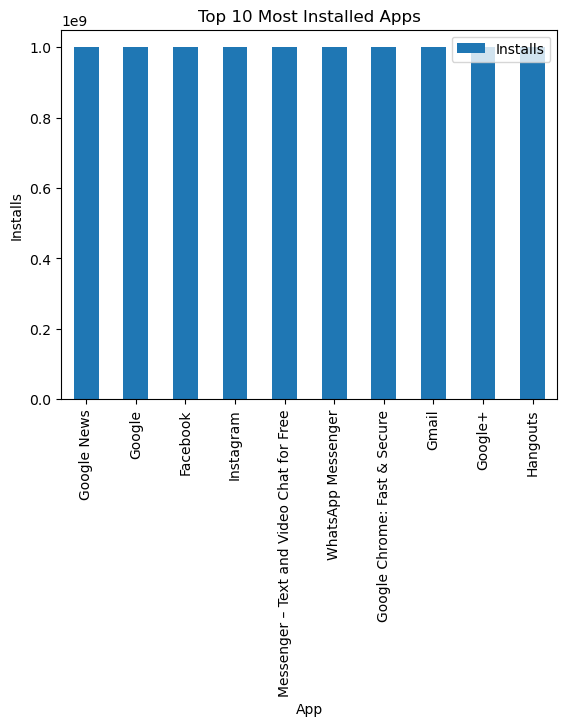

In [16]:
top_apps = apps_df[['App','Installs']].sort_values(by='Installs', ascending=False)

print(top_apps.head(10))
plt.figure(figsize=(12,6))

top_apps.head(10).plot(
    x='App',
    y='Installs',
    kind='bar'
)

plt.title('Top 10 Most Installed Apps')
plt.ylabel('Installs')

plt.show()

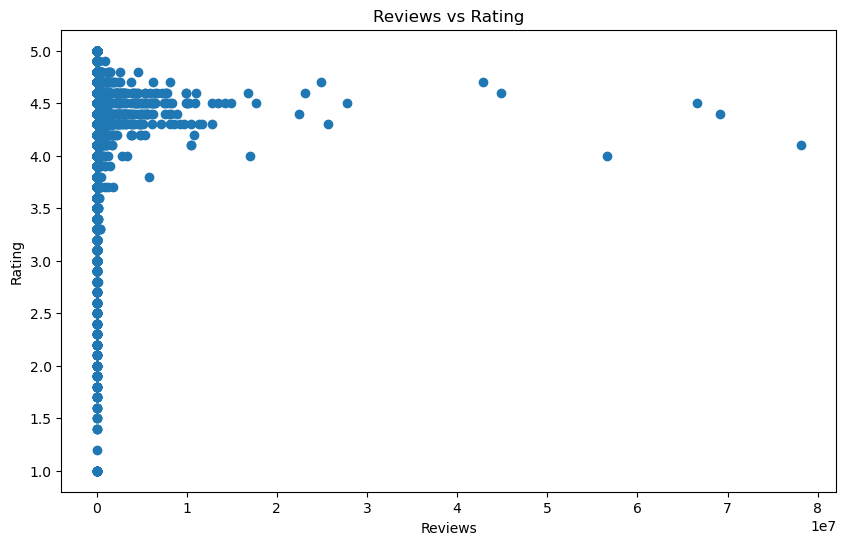

In [17]:
#Rating vs Reviews Scatter Plot
plt.figure(figsize=(10,6))

plt.scatter(apps_df['Reviews'], apps_df['Rating'])

plt.title('Reviews vs Rating')
plt.xlabel('Reviews')
plt.ylabel('Rating')

plt.show()

Cleaned apps dataset saved successfully
Cleaned reviews dataset saved successfully


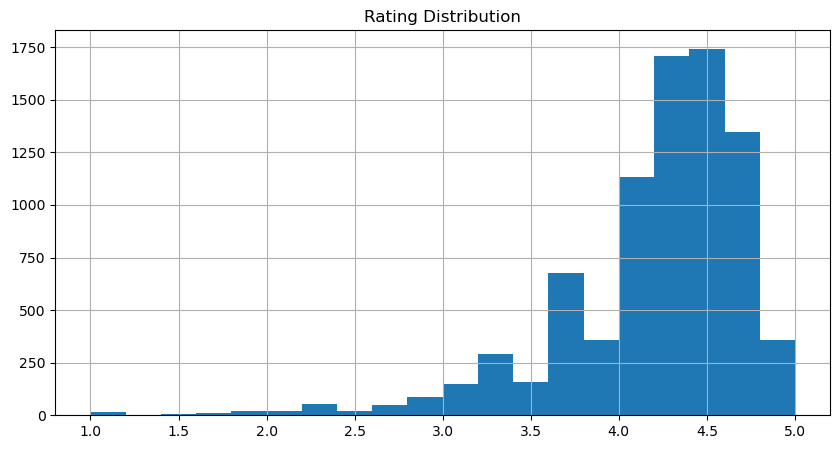

In [18]:
apps_df.to_csv("cleaned_apps.csv", index=False)

print("Cleaned apps dataset saved successfully")
reviews_df.to_csv("cleaned_user_reviews.csv", index=False)

print("Cleaned reviews dataset saved successfully")
plt.figure(figsize=(10,5))

apps_df['Rating'].hist(bins=20)

plt.title('Rating Distribution')

plt.savefig("rating_distribution.png")

plt.show()